# dlt-ibapi Quickstart Guide

This notebook demonstrates the basic usage of `dlt-ibapi` for fetching market data from Interactive Brokers.

## Prerequisites

1. IB Gateway or TWS running locally (default: localhost:7497)
2. API connections enabled in IB Gateway/TWS settings
3. `dlt-ibapi` installed: `uv add dlt-ibapi`

## Table of Contents

1. [Setup and Configuration](#1-setup-and-configuration)
2. [Fetching Historical Equity Bars](#2-fetching-historical-equity-bars)
3. [Option Chain Snapshots](#3-option-chain-snapshots)
4. [Historical Data Backfilling](#4-historical-data-backfilling)
5. [Querying Saved Data](#5-querying-saved-data)

## 1. Setup and Configuration

First, let's import the necessary libraries and configure the connection to IB Gateway.

In [1]:
import dlt
import duckdb
from datetime import date, timedelta
from pathlib import Path

# Import dlt-ibapi resources
from dlt_ibapi import ib_historical_bars, ib_source
from dlt_ibapi.config import IBConnectionConfig, IBHistoricalConfig

# Configure IB connection (adjust if needed)
ib_config = IBConnectionConfig(
    host="127.0.0.1",
    port=4002,  # IB Gateway paper trading port
    client_id=1,
    timeout=60,
    readonly=False,
)

print("✓ Configuration loaded")
print(f"  IB Gateway: {ib_config.host}:{ib_config.port}")

✓ Configuration loaded
  IB Gateway: 127.0.0.1:4002


## 2. Fetching Historical Equity Bars

Let's fetch some historical bar data for a single stock (AAPL) and save it to Parquet files.

In [2]:
# Create a DLT pipeline with Parquet storage
pipeline = dlt.pipeline(
    pipeline_name="ib_quickstart",
    destination=dlt.destinations.filesystem(bucket_url="../data"),
    dataset_name="stocks",
)

# Configure historical data settings
hist_config = IBHistoricalConfig(
    bar_size="1 day",
    duration="30 D"
)

# Fetch AAPL historical bars (last 30 days, daily bars)
data = ib_historical_bars(
    symbol="AAPL",
    exchange="SMART",
    currency="USD",
    connection_config=ib_config,
    hist_config=hist_config,
)

# Run the pipeline - data saved as Parquet with Hive partitioning
info = pipeline.run(data, loader_file_format="parquet")

print("\n✓ Pipeline completed successfully!")

# Unpack the LoadInfo structure to display metrics
# LoadInfo structure: info contains metadata about the pipeline run
#   - load_packages: List of LoadPackageInfo objects (one per load operation)
#   - metrics: Dict[load_id, List[LoadMetrics]] containing job-level metrics
if info.load_packages:
    # Each LoadPackageInfo has:
    #   - load_id: Unique identifier for this load operation
    #   - jobs: Dict with keys 'completed_jobs', 'failed_jobs', 'started_jobs', 'new_jobs'
    #   - state: Package state (e.g., 'loaded', 'normalized')
    load_package = info.load_packages[0]  # First (and typically only) package
    print(f"  Load ID: {load_package.load_id}")
    print(f"  Package state: {load_package.state}")
    
    # Access metrics from the LoadInfo.metrics dict (indexed by load_id)
    if info.metrics and load_package.load_id in info.metrics:
        # metrics[load_id] is a list, typically with one LoadMetrics object
        load_metrics = info.metrics[load_package.load_id][0]
        
        # LoadMetrics contains job_metrics: Dict[job_id, LoadJobMetrics]
        # LoadJobMetrics has: job_id, file_path, table_name, started_at, finished_at, state
        if load_metrics.get("job_metrics"):
            total_jobs = len(load_metrics["job_metrics"])
            print(f"  Jobs completed: {total_jobs}")
            
            # Show details of first job
            first_job_id = next(iter(load_metrics["job_metrics"].keys()))
            first_job = load_metrics["job_metrics"][first_job_id]
            print(f"  Table: {first_job.table_name}")
        else:
            print("  No job metrics available")
else:
    print("  No load packages found")

print(f"  Data saved to: ../data/stocks/")

IB error (no reqId) code=1761039685981 msg=2104
IB error (no reqId) code=1761039685982 msg=2107
IB error (no reqId) code=1761039685982 msg=2107
IB error (no reqId) code=1761039685982 msg=2158
IB error (no reqId) code=1761039687007 msg=2106



✓ Pipeline completed successfully!
  Load ID: 1761039685.977895
  Package state: loaded
  Jobs completed: 1
  Table: historical_bars
  Data saved to: ../data/stocks/


### Query the data immediately with DuckDB

In [3]:
# Query the Parquet files using DuckDB
conn = duckdb.connect(":memory:")

df = conn.execute("""
    SELECT 
        symbol,
        time::DATE as date,
        open,
        high,
        low,
        close,
        volume
    FROM parquet_scan('../data/stocks/**/*.parquet', hive_partitioning=true)
    WHERE symbol = 'AAPL'
    ORDER BY time DESC
    LIMIT 10
""").df()

print("\nLatest 10 bars for AAPL:")
df


Latest 10 bars for AAPL:


,symbol,date,open,high,low,close,volume
0,AAPL,2025-10-20,255.89,264.38,255.63,262.24,53855185
1,AAPL,2025-10-20,255.89,264.38,255.63,262.24,53855185
2,AAPL,2025-10-17,248.08,253.38,247.27,252.29,26059827
3,AAPL,2025-10-17,248.08,253.38,247.27,252.29,26059827
4,AAPL,2025-10-16,248.28,249.04,245.13,247.45,23521637
5,AAPL,2025-10-16,248.28,249.04,245.13,247.45,23521637
6,AAPL,2025-10-15,249.49,251.82,247.47,249.34,17213853
7,AAPL,2025-10-15,249.49,251.82,247.47,249.34,17213853
8,AAPL,2025-10-14,246.60,248.85,244.70,247.77,17603499
9,AAPL,2025-10-14,246.60,248.85,244.70,247.77,17603499


## 3. Option Chain Snapshots

Capture a snapshot of available option contracts for a symbol.

In [4]:
from dlt_ibapi.backfill.resources import snapshot_option_chain
from datetime import date

# Create pipeline for options data
options_pipeline = dlt.pipeline(
    pipeline_name="ib_options",
    destination=dlt.destinations.filesystem(bucket_url="../data"),
    dataset_name="options",
)

# Capture option chain snapshot for SPY
snapshot = snapshot_option_chain(
    underlying="SPY",
    snapshot_date=date.today(),
    cache_path=".dlt-ibapi/cache",
    connection_config=ib_config,
)

info = options_pipeline.run(snapshot, loader_file_format="parquet")

print("\n✓ Option chain snapshot saved!")
print(f"  Data saved to: ../data/options/option_chain_snapshot/")

IB error (no reqId) code=1761039687612 msg=2104
IB error (no reqId) code=1761039687612 msg=2107
IB error (no reqId) code=1761039687613 msg=2106
IB error (no reqId) code=1761039687613 msg=2158



✓ Option chain snapshot saved!
  Data saved to: ../data/options/option_chain_snapshot/


### View available option expirations

In [5]:
# Query option chain snapshot
snapshot_df = conn.execute("""
    SELECT 
        underlying,
        as_of,
        exchange,
        trading_class,
        expiration_count,
        strike_count
    FROM parquet_scan('../data/options/option_chain_snapshot/**/*.parquet', hive_partitioning=true)
    WHERE underlying = 'SPY'
    ORDER BY as_of DESC
    LIMIT 5
""").df()

print("\nOption chain snapshots for SPY:")
snapshot_df


Option chain snapshots for SPY:


,underlying,as_of,exchange,trading_class,expiration_count,strike_count
0,SPY,2025-10-21,NASDAQOM,SPY,22,363
1,SPY,2025-10-21,AMEX,SPY,22,363
2,SPY,2025-10-21,CBOE2,2SPY,2,2
3,SPY,2025-10-21,NASDAQBX,SPY,22,363
4,SPY,2025-10-21,CBOE,2SPY,2,2


In [6]:
# Show detailed expirations and strikes for SPY on AMEX
# DLT stores nested arrays (expirations, strikes) in separate child tables
# linked via _dlt_parent_id to the parent snapshot table

# Query expirations for SPY AMEX
expirations_df = conn.execute("""
    SELECT 
        s.underlying,
        s.exchange,
        s.trading_class,
        e.value as expiration,
        strptime(e.value, '%Y%m%d')::DATE as expiration_date
    FROM parquet_scan('../data/options/option_chain_snapshot/**/*.parquet', hive_partitioning=true) s
    JOIN parquet_scan('../data/options/option_chain_snapshot__expirations/**/*.parquet', hive_partitioning=true) e
        ON s._dlt_id = e._dlt_parent_id
    WHERE s.underlying = 'SPY' AND s.exchange = 'AMEX'
    ORDER BY e.value
    LIMIT 10
""").df()

print("\nFirst 10 expirations for SPY on AMEX:")
print(expirations_df)

print()

# Query strikes for SPY AMEX (show a sample around current price)
strikes_df = conn.execute("""
    SELECT 
        s.underlying,
        s.exchange,
        k.value as strike
    FROM parquet_scan('../data/options/option_chain_snapshot/**/*.parquet', hive_partitioning=true) s
    JOIN parquet_scan('../data/options/option_chain_snapshot__strikes/**/*.parquet', hive_partitioning=true) k
        ON s._dlt_id = k._dlt_parent_id
    WHERE s.underlying = 'SPY' AND s.exchange = 'AMEX'
    ORDER BY k.value
    LIMIT 20
""").df()

print("\nFirst 20 strikes for SPY on AMEX:")
print(strikes_df)


First 10 expirations for SPY on AMEX:
  underlying exchange trading_class expiration expiration_date
0        SPY     AMEX           SPY   20251028      2025-10-28
1        SPY     AMEX           SPY   20251029      2025-10-29
2        SPY     AMEX           SPY   20251030      2025-10-30
3        SPY     AMEX           SPY   20251031      2025-10-31
4        SPY     AMEX           SPY   20251103      2025-11-03
5        SPY     AMEX           SPY   20251104      2025-11-04
6        SPY     AMEX           SPY   20251107      2025-11-07
7        SPY     AMEX           SPY   20251114      2025-11-14
8        SPY     AMEX           SPY   20251121      2025-11-21
9        SPY     AMEX           SPY   20251128      2025-11-28


First 20 strikes for SPY on AMEX:
   underlying exchange  strike
0         SPY     AMEX   150.0
1         SPY     AMEX   155.0
2         SPY     AMEX   160.0
3         SPY     AMEX   165.0
4         SPY     AMEX   170.0
5         SPY     AMEX   175.0
6         SPY  

## 4. Historical Data Backfilling

Backfill historical data with gap detection (only fetches missing dates).

In [7]:
from dlt_ibapi.backfill.resources import backfill_equity_bars

# Backfill MSFT daily bars for the last 30 days
backfill_data = backfill_equity_bars(
    symbol="MSFT",
    database_path="../data",
    dataset_name="stocks",
    connection_config=ib_config,
    start_date=date.today() - timedelta(days=30),
    end_date=date.today(),
    bar_size="1 day",
)

info = pipeline.run(backfill_data, loader_file_format="parquet")

print("\n✓ Backfill completed!")
print("  Note: Gap detection ensures only missing dates are fetched")

IB error (no reqId) code=1761039688416 msg=2104
IB error (no reqId) code=1761039688416 msg=2107
IB error (no reqId) code=1761039688417 msg=2106
IB error (no reqId) code=1761039688417 msg=2158
IB API returned error 2174 for 2025-09-22 to 2025-09-26. Gap may contain non-trading days (holidays/weekends). Full error: IB error 1761039688556: 2174



✓ Backfill completed!
  Note: Gap detection ensures only missing dates are fetched


### Re-run backfill (demonstrates idempotency)

In [8]:
# Run the same backfill again - it should skip all dates (gap detection)
backfill_data_2 = backfill_equity_bars(
    symbol="MSFT",
    database_path="../data",
    dataset_name="stocks",
    connection_config=ib_config,
    start_date=date.today() - timedelta(days=30),
    end_date=date.today(),
    bar_size="1 day",
)

info = pipeline.run(backfill_data_2, loader_file_format="parquet")

print("\n✓ Second backfill completed!")
print("  Should have skipped most/all dates (idempotent)")

IB error (no reqId) code=1761039690074 msg=2104
IB error (no reqId) code=1761039690074 msg=2107
IB error (no reqId) code=1761039690075 msg=2106
IB error (no reqId) code=1761039690077 msg=2158
IB API returned error 2174 for 2025-09-22 to 2025-09-26. Gap may contain non-trading days (holidays/weekends). Full error: IB error 1761039690098: 2174



✓ Second backfill completed!
  Should have skipped most/all dates (idempotent)


## 5. Querying Saved Data

Query all the data we've collected using DuckDB.

In [9]:
# Get summary of all symbols
summary_df = conn.execute("""
    SELECT 
        symbol,
        bar_size,
        COUNT(*) as bar_count,
        MIN(time::DATE) as first_date,
        MAX(time::DATE) as last_date,
        ROUND(AVG(volume), 0) as avg_volume
    FROM parquet_scan('../data/stocks/**/*.parquet', hive_partitioning=true)
    GROUP BY symbol, bar_size
    ORDER BY symbol
""").df()

print("\nSummary of collected data:")
summary_df


Summary of collected data:


,symbol,bar_size,bar_count,first_date,last_date,avg_volume
0,AAPL,1 day,60,2025-09-09,2025-10-20,30505552.0
1,MSFT,1 day,64,2025-09-29,2025-10-20,6930695.0


### Visualize price data

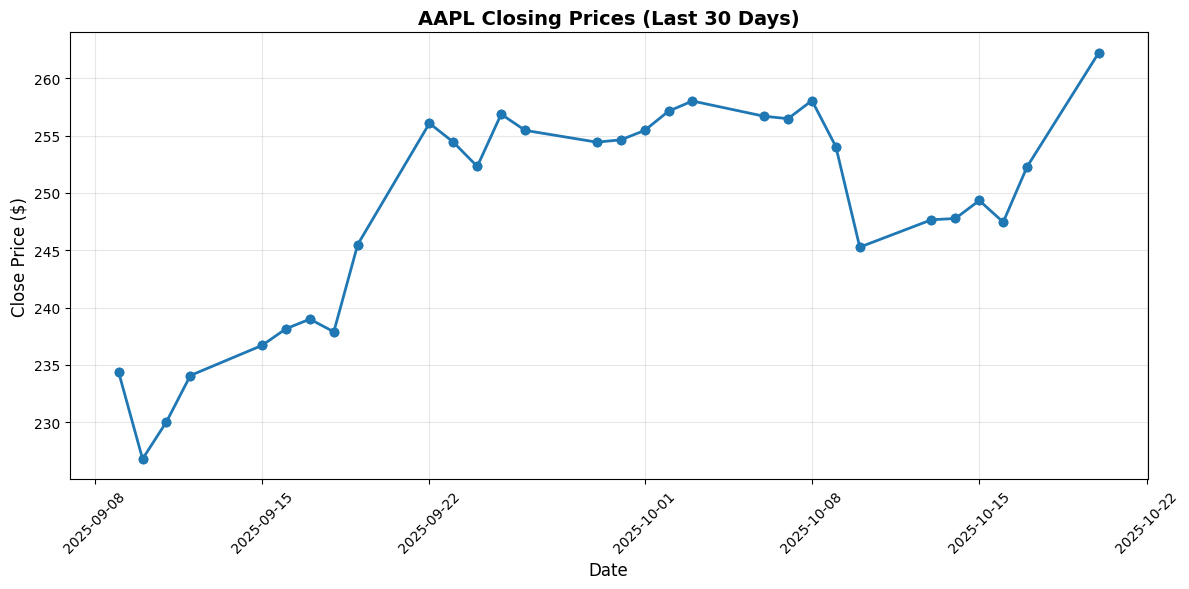


✓ Plotted 60 data points for AAPL


In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Get AAPL data for plotting
aapl_df = conn.execute("""
    SELECT 
        time::DATE as date,
        close
    FROM parquet_scan('../data/stocks/**/*.parquet', hive_partitioning=true)
    WHERE symbol = 'AAPL'
    ORDER BY time
""").df()

# Plot closing prices
plt.figure(figsize=(12, 6))
plt.plot(aapl_df['date'], aapl_df['close'], marker='o', linewidth=2)
plt.title('AAPL Closing Prices (Last 30 Days)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\n✓ Plotted {len(aapl_df)} data points for AAPL")

## Summary

In this quickstart notebook, you learned how to:

1. ✓ Configure connection to IB Gateway/TWS
2. ✓ Fetch historical equity bars using `ib_historical_bars`
3. ✓ Capture option chain snapshots
4. ✓ Backfill historical data with gap detection
5. ✓ Query saved Parquet data with DuckDB
6. ✓ Visualize market data

### Next Steps

- Check out `02_reading_data.ipynb` to learn more about querying Parquet data
- Explore the `examples/` directory for more advanced usage
- Read the documentation at `docs/BACKFILL_GUIDE.md`

### Data Storage

All data is stored as Parquet files with Hive-style partitioning:

```
data/
├── stocks/
│   └── date=2025-10-20/
│       ├── symbol=AAPL/*.parquet
│       └── symbol=MSFT/*.parquet
└── options/
    └── option_chain_snapshot/
        └── date=2025-10-20/
            └── underlying=SPY/*.parquet
```

Benefits:
- 10x better compression vs. raw databases
- Predicate pushdown for fast filtering
- Cloud storage ready (S3, GCS, Azure)

### AAPL Price vs Business Days

Compare actual trading days with calendar business days to visualize market holidays.

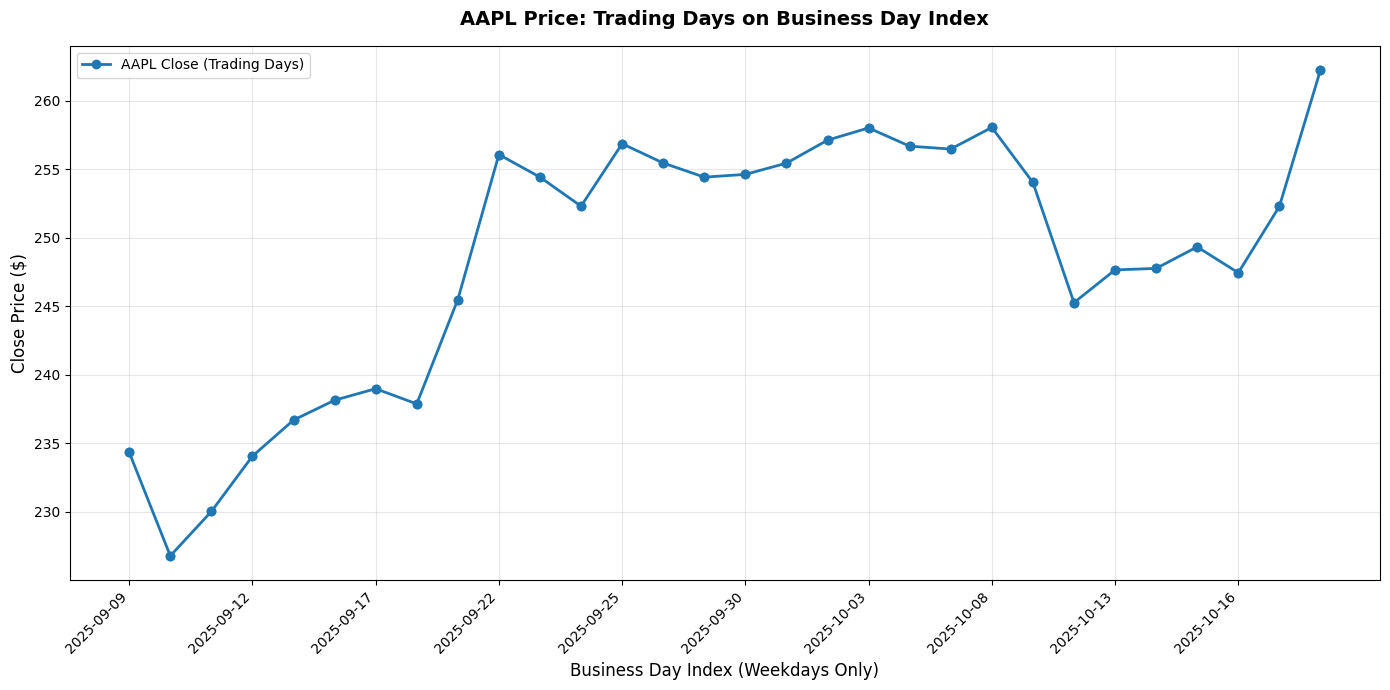


✓ Analysis complete:
  Total trading days: 60
  Total business days: 30
  Market holidays in range: 0

  No market holidays detected in this date range


In [11]:
import matplotlib.pyplot as plt
import pandas as pd
from pandas.tseries.offsets import BDay

# Get AAPL data
aapl_df = conn.execute("""
    SELECT 
        time::DATE as date,
        close
    FROM parquet_scan('../data/stocks/**/*.parquet', hive_partitioning=true)
    WHERE symbol = 'AAPL'
    ORDER BY time
""").df()

# Convert date column to datetime
aapl_df['date'] = pd.to_datetime(aapl_df['date'])

# Create a range of business days (excludes weekends only, not holidays)
min_date = aapl_df['date'].min()
max_date = aapl_df['date'].max()
business_days = pd.date_range(start=min_date, end=max_date, freq=BDay())

# Create DataFrame for business days with index
business_df = pd.DataFrame({
    'date': business_days,
    'business_day_index': range(len(business_days))
})

# Merge AAPL data with business day index
merged = business_df.merge(aapl_df, on='date', how='left')

# Identify missing trading days (holidays)
holidays = merged[merged['close'].isna()].copy()
trading_days = merged[merged['close'].notna()].copy()

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

# Plot actual trading day prices using business day index
ax.plot(trading_days['business_day_index'], trading_days['close'], 
        marker='o', linewidth=2, markersize=6, 
        label='AAPL Close (Trading Days)', 
        color='#1f77b4', zorder=3)

# Mark business days that are NOT trading days (holidays) with red X
if len(holidays) > 0:
    ax.scatter(holidays['business_day_index'], 
              [trading_days['close'].mean()] * len(holidays),
              marker='x', s=200, color='red', linewidth=3,
              label='Market Holiday', zorder=4)

# Styling
ax.set_title('AAPL Price: Trading Days on Business Day Index', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Business Day Index (Weekdays Only)', fontsize=12)
ax.set_ylabel('Close Price ($)', fontsize=12)
ax.grid(True, alpha=0.3, zorder=0)

# Set x-axis ticks to show actual dates at intervals
tick_interval = max(1, len(business_df) // 10)  # Show ~10 ticks
tick_positions = business_df['business_day_index'][::tick_interval]
tick_labels = business_df['date'][::tick_interval].dt.strftime('%Y-%m-%d')
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha='right')

ax.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

# Print summary
print(f"\n✓ Analysis complete:")
print(f"  Total trading days: {len(trading_days)}")
print(f"  Total business days: {len(business_days)}")
print(f"  Market holidays in range: {len(holidays)}")

if len(holidays) > 0:
    print(f"\n  Holidays identified (business days with no trading):")
    for _, row in holidays.iterrows():
        print(f"    - {row['date'].strftime('%Y-%m-%d (%A)')} at index {row['business_day_index']}")
else:
    print(f"\n  No market holidays detected in this date range")